## Logistische Regression mit  PCA

In [10]:
# setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml    # lädt den Datensatz von OpenML

from sklearn.compose import ColumnTransformer    # verarbeitet diverse Spalten vor
from sklearn.pipeline import Pipeline      # # Verbindet mehrere Verarbeitungsschritte zu einer Pipeline
from sklearn.impute import SimpleImputer   # Ersetzt fehlende Werte (NaN) durch einen festgelegten Wert
from sklearn.preprocessing import StandardScaler, OneHotEncoder   # standardisiert numerische Variablen + wandelt kategoriale Variablen in numerische 0/1-Spalten um
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score   # teilt die Daten für Cross-Validation in mehrere Folds auf + trainiert und evaluiert das Modell automatisch
from sklearn.metrics import roc_curve, roc_auc_score   # Berechnet den ROC-AUC-Wert 
from sklearn.model_selection import cross_val_predict

from sklearn.decomposition import PCA

RANDOM_STATE = 42

In [11]:
# daten laden

def load_porto_seguro() -> pd.DataFrame:
    """Lädt den Porto-Seguro-Datensatz von OpenML (target als int 0/1, fehlend = NaN)."""
    ds = fetch_openml(data_id=42742, as_frame=True, parser="auto")
    df = ds.frame.rename(columns={ds.target.name: "target"})
    df["target"] = df["target"].astype(int)
    return df

def build_meta(df: pd.DataFrame) -> pd.DataFrame:
    """Leitet Rolle, Skalenniveau und Gruppe jedes Features aus dem Namen ab."""
    rows = []
    for col in df.columns:
        role = "target" if col == "target" else ("id" if col == "id" else "input")
        if col in ("id", "target"):
            level = col
        elif col.endswith("bin"):
            level = "binary"
        elif col.endswith("cat"):
            level = "nominal"
        elif pd.api.types.is_numeric_dtype(df[col]):
            level = "interval" if (df[col].dropna() % 1 != 0).any() else "ordinal"
        else:
            level = "nominal"
        group = col.split("_")[1] if col.startswith("ps_") else "meta"
        rows.append({"varname": col, "role": role, "level": level, "group": group,
                     "dtype": str(df[col].dtype), "n_missing": int(df[col].isna().sum()),
                     "n_unique": int(df[col].nunique())})
    return pd.DataFrame(rows).set_index("varname")

def column_groups(meta: pd.DataFrame) -> dict:
    return {"bin": meta.index[meta.level == "binary"].tolist(),
            "cat": meta.index[meta.level == "nominal"].tolist(),
            "num": meta.index[meta.level.isin(["interval", "ordinal"])].tolist()}

# laden
train = load_porto_seguro()
meta  = build_meta(train)
cols  = column_groups(meta)
bin_cols, cat_cols, num_cols = cols["bin"], cols["cat"], cols["num"]
print(f"{len(bin_cols)} binär · {len(cat_cols)} kategorial · {len(num_cols)} numerisch")

17 binär · 14 kategorial · 26 numerisch


In [12]:
# Feature-Matrix und target trennen. Binär + numerisch als Zahlen, kategorial als Objekt (für OHE).

numeric_features = num_cols + bin_cols
categorical_features = cat_cols

# Zielvariable und ID aus der Feature-Matrix entfernen
X = train.drop(columns=["target", "id"], errors="ignore").copy()

X[numeric_features]     = X[numeric_features].apply(pd.to_numeric, errors="coerce")
X[categorical_features] = X[categorical_features].astype(object)
y = train["target"].astype(int)

# Normalisierter Gini (2 x AUC − 1)
def gini_normalized(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [14]:
# Numerische Features: Imputation, Skalierung und PCA

numeric_pipe_pca = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
])

# Binäre Features: fehlende Werte imputieren, aber keine PCA
binary_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
])

# Kategoriale Features: fehlende Werte und One-Hot-Encoding
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(
        strategy="constant",
        fill_value="MISSING"
    )),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=50
    )),
])

pre_pca = ColumnTransformer([
    ("num_pca", numeric_pipe_pca, num_cols),
    ("bin", binary_pipe, bin_cols),
    ("cat", categorical_pipe, cat_cols),
])

model_pca = Pipeline([
    ("pre", pre_pca),
    ("clf", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])

In [15]:
auc_pca = cross_val_score(
    model_pca,
    X,
    y,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

gini_pca = 2 * auc_pca - 1

print("AUC je Fold: ", np.round(auc_pca, 4))
print("Gini je Fold:", np.round(gini_pca, 4))

print(f"AUC  (PCA): {auc_pca.mean():.4f} ± {auc_pca.std():.4f}")
print(f"Gini (PCA): {gini_pca.mean():.4f} ± {gini_pca.std():.4f}")

AUC je Fold:  [0.6326 0.6274 0.6295 0.6322 0.6243]
Gini je Fold: [0.2651 0.2548 0.2589 0.2644 0.2486]
AUC  (PCA): 0.6292 ± 0.0031
Gini (PCA): 0.2584 ± 0.0062


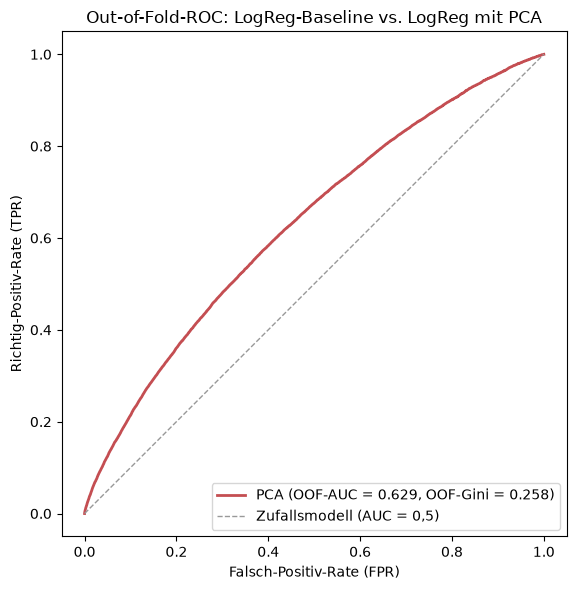

In [23]:
# plot

# Out-of-Fold-ROC-Vergleich

fig, ax = plt.subplots(figsize=(6, 6))

colors = {
    "Baseline": "#4C72B0",
    "PCA": "#C44E52"
}

models = {
    "PCA": model_pca
}

for name, mdl in models.items():
    # Jede Beobachtung wird von einem Modell vorhergesagt,
    # das diese Beobachtung nicht im Training gesehen hat.
    y_proba_oof = cross_val_predict(
        mdl,
        X,
        y,
        cv=skf,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    fpr, tpr, _ = roc_curve(y, y_proba_oof)
    auc_oof = roc_auc_score(y, y_proba_oof)
    gini_oof = 2 * auc_oof - 1

    ax.plot(
        fpr,
        tpr,
        lw=2,
        color=colors[name],
        label=(
            f"{name} "
            f"(OOF-AUC = {auc_oof:.3f}, "
            f"OOF-Gini = {gini_oof:.3f})"
        )
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#999",
    linewidth=1,
    label="Zufallsmodell (AUC = 0,5)"
)

ax.set_xlabel("Falsch-Positiv-Rate (FPR)")
ax.set_ylabel("Richtig-Positiv-Rate (TPR)")
ax.set_title("Out-of-Fold-ROC: LogReg-Baseline vs. LogReg mit PCA")
ax.legend(loc="lower right")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()